# Преобразуем текст в векторы

### Зачем нужны векторы?

Компьютер плохо работает со смыслом, буквами. Он умеет хорошо работать только с цифрами. Поэтому чтобы сравнивать тексты, мы преобразуем их в наборы чисел

Набор чисел в программировании называют вектором. Вам должно быть знакомо это понятие из математики и физики. Давайте вспомним, что оно означает.

- Пусть мы работаем на плоскости, то есть у нас только 2 координаты`(x, y)`. Как задать вектор?
- Что может означать вектор? Подсказка: вспомните пространство RGB
- Как можно понять, что векторы близки друг к другу?

Построим векторы в пространстве RG для демонстрации



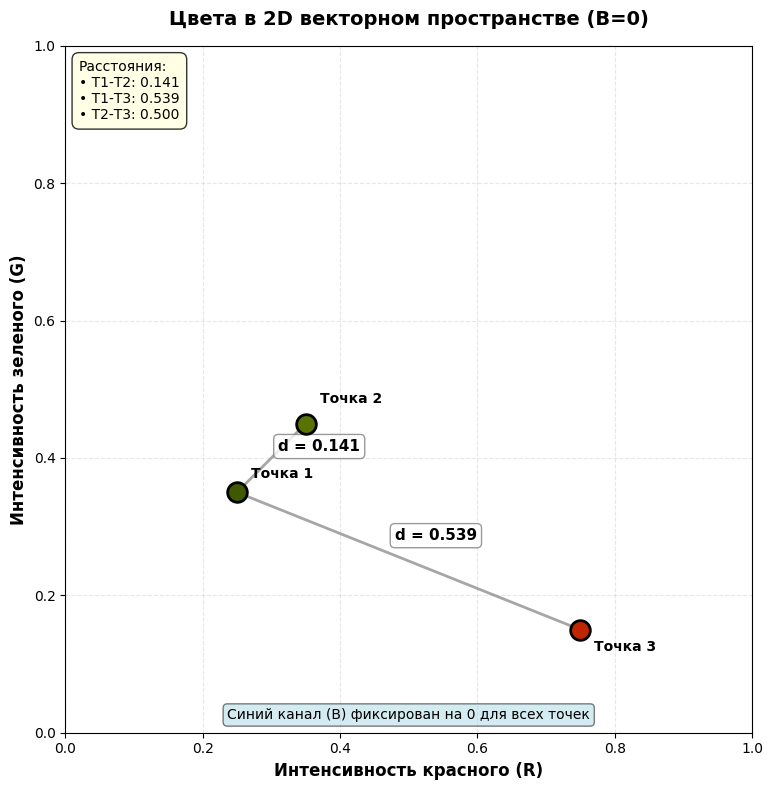

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

# Создаем фигуру
fig, ax = plt.subplots(figsize=(10, 8))

# Настраиваем оси
ax.set_xlabel('Интенсивность красного (R)', fontsize=12, fontweight='bold')
ax.set_ylabel('Интенсивность зеленого (G)', fontsize=12, fontweight='bold')
ax.set_title('Цвета в 2D векторном пространстве (B=0)', fontsize=14, fontweight='bold', pad=15)

# Устанавливаем пределы осей
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect('equal')  # Сохраняем пропорции, чтобы расстояния были корректными

# Добавляем сетку для наглядности
ax.grid(True, linestyle='--', alpha=0.3)

# Определяем точки (R, G, B) где B=0 всегда
# Две близкие точки
point1 = (0.25, 0.35)  # RGB: (0.25, 0.35, 0)
point2 = (0.35, 0.45)  # RGB: (0.35, 0.45, 0)

# Третья удаленная точка
point3 = (0.75, 0.15)  # RGB: (0.75, 0.15, 0)

# Преобразуем в цвета для отображения
color1 = (point1[0], point1[1], 0)  # (R, G, 0)
color2 = (point2[0], point2[1], 0)  # (R, G, 0)
color3 = (point3[0], point3[1], 0)  # (R, G, 0)

# Рисуем точки
ax.scatter(*point1, s=200, color=color1, edgecolors='black', linewidth=2, zorder=5, label=f'Точка 1: {color1}')
ax.scatter(*point2, s=200, color=color2, edgecolors='black', linewidth=2, zorder=5, label=f'Точка 2: {color2}')
ax.scatter(*point3, s=200, color=color3, edgecolors='black', linewidth=2, zorder=5, label=f'Точка 3: {color3}')

# Вычисляем расстояния (евклидовы)
dist_1_2 = np.sqrt((point2[0] - point1[0])**2 + (point2[1] - point1[1])**2)
dist_1_3 = np.sqrt((point3[0] - point1[0])**2 + (point3[1] - point1[1])**2)
dist_2_3 = np.sqrt((point3[0] - point2[0])**2 + (point3[1] - point2[1])**2)

# Рисуем линии между точками
ax.plot([point1[0], point2[0]], [point1[1], point2[1]], 'gray', linewidth=2, linestyle='-', alpha=0.7)
ax.plot([point1[0], point3[0]], [point1[1], point3[1]], 'gray', linewidth=2, linestyle='-', alpha=0.7)

# Добавляем подписи расстояний
# Расстояние между точками 1 и 2 (посередине линии)
mid_point_12 = ((point1[0] + point2[0])/2, (point1[1] + point2[1])/2)
ax.annotate(f'd = {dist_1_2:.3f}', xy=mid_point_12, xytext=(5, 5),
            textcoords='offset points', fontsize=11, fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8, edgecolor='gray'))

# Расстояние между точками 1 и 3 (посередине линии)
mid_point_13 = ((point1[0] + point3[0])/2, (point1[1] + point3[1])/2)
ax.annotate(f'd = {dist_1_3:.3f}', xy=mid_point_13, xytext=(-10, 15),
            textcoords='offset points', fontsize=11, fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8, edgecolor='gray'))



# Добавляем легенду с цветовыми патчами
legend_elements = [
    mpatches.Patch(facecolor=color1, edgecolor='black', label=f'Точка 1: {color1}'),
    mpatches.Patch(facecolor=color2, edgecolor='black', label=f'Точка 2: {color2}'),
    mpatches.Patch(facecolor=color3, edgecolor='black', label=f'Точка 3: {color3}'),
]

# Добавляем подписи к точкам
ax.annotate('Точка 1', xy=point1, xytext=(10, 10), textcoords='offset points',
            fontsize=10, fontweight='bold')
ax.annotate('Точка 2', xy=point2, xytext=(10, 15), textcoords='offset points',
            fontsize=10, fontweight='bold')
ax.annotate('Точка 3', xy=point3, xytext=(10, -15), textcoords='offset points',
            fontsize=10, fontweight='bold')

# Добавляем информационную панель
info_text = f'Расстояния:\n• Т1-Т2: {dist_1_2:.3f}\n• Т1-Т3: {dist_1_3:.3f}\n• Т2-Т3: {dist_2_3:.3f}'
ax.text(0.02, 0.98, info_text, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=dict(boxstyle="round,pad=0.5", facecolor="lightyellow", alpha=0.8))

# Добавляем пояснение про синий канал
ax.text(0.5, 0.02, 'Синий канал (B) фиксирован на 0 для всех точек',
        transform=ax.transAxes, fontsize=10, ha='center',
        bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.5))

plt.tight_layout()
plt.show()


Вернемся к словам. Как можно разложить слово на 2 числа? Например, ось X - модность`(хайповость)` слова, Y - женственность слова.

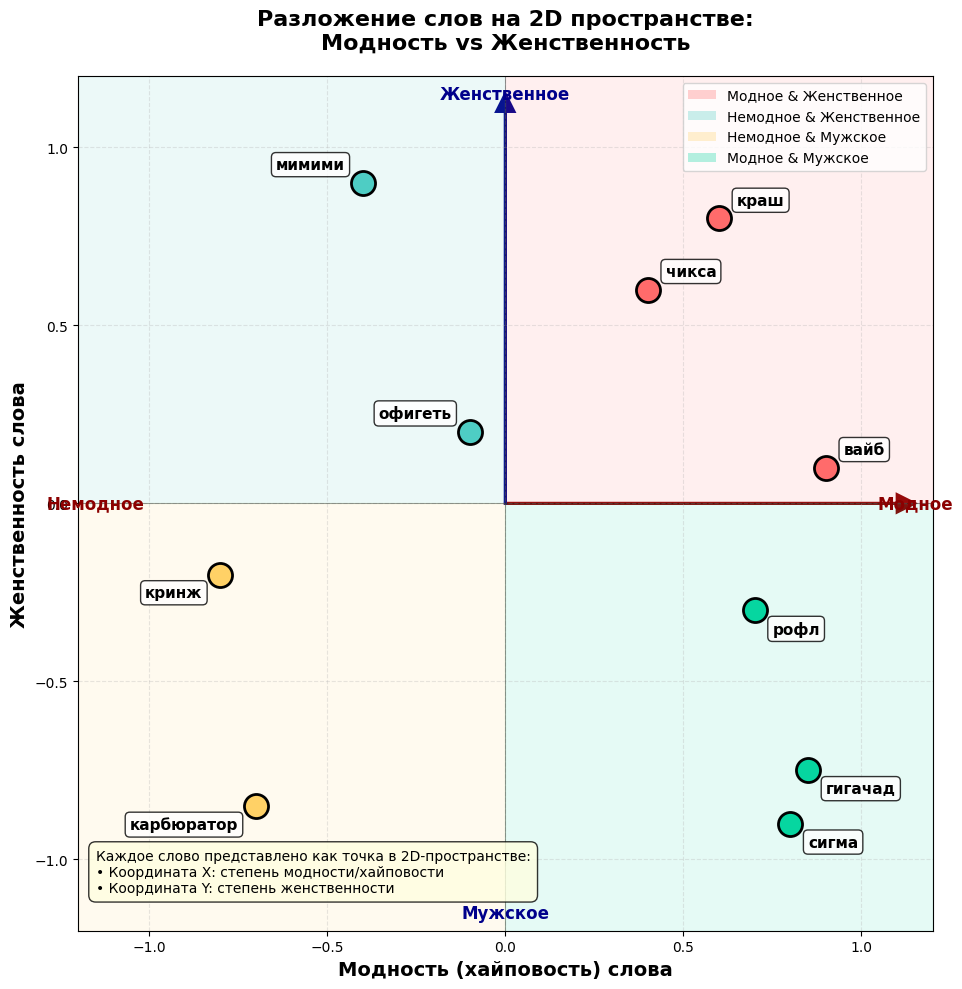

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Создаем фигуру
fig, ax = plt.subplots(figsize=(12, 10))

# Настраиваем оси
ax.set_xlabel('Модность (хайповость) слова', fontsize=14, fontweight='bold')
ax.set_ylabel('Женственность слова', fontsize=14, fontweight='bold')
ax.set_title('Разложение слов на 2D пространстве:\nМодность vs Женственность',
             fontsize=16, fontweight='bold', pad=20)

# Устанавливаем пределы осей
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.set_aspect('equal')

# Добавляем центральные линии осей
ax.axhline(y=0, color='black', linewidth=0.5, alpha=0.5)
ax.axvline(x=0, color='black', linewidth=0.5, alpha=0.5)

# Добавляем сетку
ax.grid(True, linestyle='--', alpha=0.3)

# Определяем слова и их координаты (модность, женственность)
# Обновленные координаты с новыми мужскими словами
words = {
    "кринж": (-0.8, -0.2),     # Немодное, нейтральное
    "рофл": (0.7, -0.3),       # Модное, мужское
    "вайб": (0.9, 0.1),        # Очень модное, слегка женственное
    "краш": (0.6, 0.8),        # Модное, женственное
    "сигма": (0.8, -0.9),      # Модное, очень мужское (современный интернет-сленг)
    "офигеть": (-0.1, 0.2),    # Среднее по всем параметрам
    "мимими": (-0.4, 0.9),     # Немодное, очень женственное
    "карбюратор": (-0.7, -0.85), # Техническое, немодное, очень мужское
    "гигачад": (0.85, -0.75),  # Очень модное, очень мужское (интернет-культура)
    "чикса": (0.4, 0.6),       # Модное, женственное
}

# Цвета для разных квадрантов
colors = {
    'I': '#FF6B6B',   # Правый верхний (модное, женственное) - красный
    'II': '#4ECDC4',  # Левый верхний (немодное, женственное) - бирюзовый
    'III': '#FFD166', # Левый нижний (немодное, мужское) - желтый
    'IV': '#06D6A0'   # Правый нижний (модное, мужское) - зеленый
}

# Рисуем точки для слов
for word, (x, y) in words.items():
    # Определяем квадрант для цвета
    if x >= 0 and y >= 0:
        color = colors['I']
        quadrant = "Модное & Женственное"
    elif x < 0 and y >= 0:
        color = colors['II']
        quadrant = "Немодное & Женственное"
    elif x < 0 and y < 0:
        color = colors['III']
        quadrant = "Немодное & Мужское"
    else:
        color = colors['IV']
        quadrant = "Модное & Мужское"

    # Рисуем точку
    ax.scatter(x, y, s=300, color=color, edgecolors='black', linewidth=2, zorder=5)

    # Добавляем текст со словом
    offset_x = 0.05
    offset_y = 0.03

    # Размещаем подпись в зависимости от квадранта
    if x >= 0:
        ha = 'left'
        offset_x = 0.05
    else:
        ha = 'right'
        offset_x = -0.05

    if y >= 0:
        va = 'bottom'
        offset_y = 0.03
    else:
        va = 'top'
        offset_y = -0.03

    ax.annotate(word, xy=(x, y), xytext=(x + offset_x, y + offset_y),
                fontsize=11, fontweight='bold', ha=ha, va=va,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

# Добавляем стрелки осей
ax.arrow(0, 0, 1.1, 0, head_width=0.05, head_length=0.05, fc='darkred', ec='darkred', linewidth=2)
ax.arrow(0, 0, 0, 1.1, head_width=0.05, head_length=0.05, fc='darkblue', ec='darkblue', linewidth=2)

# Подписи к краям осей
ax.text(1.15, 0, 'Модное', fontsize=12, fontweight='bold', ha='center', va='center', color='darkred')
ax.text(-1.15, 0, 'Немодное', fontsize=12, fontweight='bold', ha='center', va='center', color='darkred')
ax.text(0, 1.15, 'Женственное', fontsize=12, fontweight='bold', ha='center', va='center', color='darkblue')
ax.text(0, -1.15, 'Мужское', fontsize=12, fontweight='bold', ha='center', va='center', color='darkblue')

# Добавляем пояснительные квадранты
for quadrant, color in colors.items():
    if quadrant == 'I':
        ax.fill_between([0, 1.2], 0, 1.2, color=color, alpha=0.1)
    elif quadrant == 'II':
        ax.fill_between([-1.2, 0], 0, 1.2, color=color, alpha=0.1)
    elif quadrant == 'III':
        ax.fill_between([-1.2, 0], -1.2, 0, color=color, alpha=0.1)
    elif quadrant == 'IV':
        ax.fill_between([0, 1.2], -1.2, 0, color=color, alpha=0.1)

# Добавляем информационный блок
info_text = "Каждое слово представлено как точка в 2D-пространстве:\n• Координата X: степень модности/хайповости\n• Координата Y: степень женственности"
ax.text(-1.15, -1.1, info_text, fontsize=10, ha='left', va='bottom',
        bbox=dict(boxstyle="round,pad=0.5", facecolor="lightyellow", alpha=0.8))

# Создаем легенду для квадрантов
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=colors['I'], alpha=0.3, label='Модное & Женственное'),
    Patch(facecolor=colors['II'], alpha=0.3, label='Немодное & Женственное'),
    Patch(facecolor=colors['III'], alpha=0.3, label='Немодное & Мужское'),
    Patch(facecolor=colors['IV'], alpha=0.3, label='Модное & Мужское'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

# Добавляем пример вектора (стрелку от одного слова к другому)
# Покажем вектор от "офигеть" к "вайб" как пример
start_word = "офигеть"
end_word = "вайб"
start_coords = words[start_word]
end_coords = words[end_word]



plt.tight_layout()
plt.show()


Аналогично можно преобразовать текст в вектор. Вопрос: если каждое слово текста мы можем преобразовать в вектор, то как получить вектор текста?

На самом дея идея оценивать что-то при помощи 2-х координат вам знакома, если вы встречались с политическими координатами


[мем 1](https://sun9-43.userapi.com/s/v1/ig2/CSWpigUyMPKnPPdlgJIUuOvI8zuXoEAlL6EBVX8OvuC1rYQUuENqSS0pLMSrfbFb1f2pxhdef3-exZ9PvTdc_aUF.jpg?quality=95&as=32x36,48x53,72x80,108x120,160x178,240x267,360x400,480x533,540x600,640x711,720x800,970x1078&from=bu&cs=970x0)

[мем 2](https://sun9-24.userapi.com/s/v1/ig2/CFTRNa9iS5SO82YZAkCowx070m56Bo_FXxsXOJ_qjoDiaQ9h1VMTi-wyrdGOS050wM7ZmwP4dQfdefIs_jYV6jTt.jpg?quality=95&as=32x35,48x52,72x78,108x117,160x174,240x261,360x392,480x522,540x587,640x696,706x768&from=bu&cs=706x0)

[мем 3](https://sun9-23.userapi.com/s/v1/ig2/VYUnMJiak4w2U_TMJgL2_p7dhlSuSTuILgIFl2ux_30BSQhV8vt2y27Yts_tGRVt7WuSqjKy3wG9MnpBrjKCfrnD.jpg?quality=95&as=32x32,48x48,72x72,108x108,160x159,240x239,360x359,480x478,540x538,640x638,720x717,807x804&from=bu&cs=807x0)


Однако, в программировании мы зачастую работаем не с 2-х мерными и даже на 3-х мерными. А с 30-мерными и 100-мерными векторами. Мозг человека не может их представить визуально, но при помощи математических вычислений мы можем понять, насколько один вектор близок к другому

(кв.м, кол-во сан. узлов, кол-во комнат, кол-во розеток, стоимость ремонта, кол-во окон)

### Что общего между мешком слов и преобразованием в вектор?

Код для полчения мешка слов

In [ ]:
иtexts_training = [
     ['два', 'друг', 'идти', 'дом', 'дорога', 'лес'],
     ['согласие', 'работа', 'пиво', 'купить', 'пиво']
]

# Посчитаем самые частые слова
# Отберем 5
# В порядке убыания частоты присвоим порядковые номера
# Преобразовать тексты в векторы

from collections import Counter

counter = Counter()
for text in texts_training:
    counter.update(text)

word_position_dict = {}

for index, pair in enumerate(counter.most_common(5)):
    word = pair[0]
    word_position_dict[word] = index


vectors_training = []
for text in texts_training:
    vector_current = [0] * len(word_position_dict)
    for word in text:
        if word in word_position_dict:
            index = word_position_dict[word]
            vector_current[index] += 1
    vectors_training.append(vector_current)


print(vectors_training)

[[0, 1, 1, 1, 1], [2, 0, 0, 0, 0]]


## Домашнее задание

Напишите код, который создаст 2 файла json:
1.  Будет содержать названия документов и вектор мешка слова для каждого из них
2.  Словарь, где ключ - слово, а значение - порядковый номер в векторе